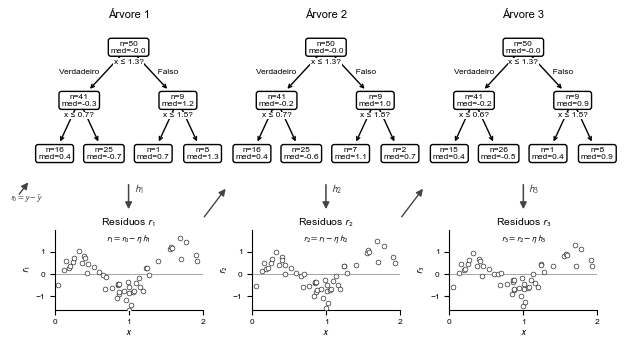

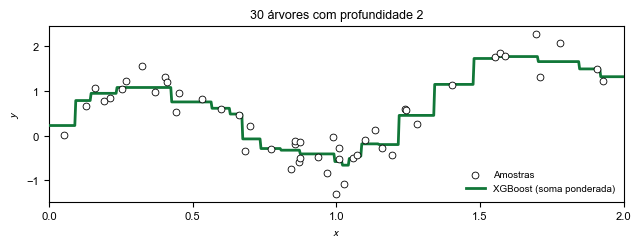

In [3]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch
from sklearn.tree import DecisionTreeRegressor, plot_tree
import numpy as np
 
cm = 1 / 2.54
 
plt.rcParams.update({
    "font.family": "Arial",
    "mathtext.fontset": "stixsans",
    "font.size": 8,
})
 
COR_XGB = "#117738"
COR_SETA = "#444444"
 
 
def encurtar_texto(text):
    out = (text
           .replace("True", "Verdadeiro")
           .replace("False", "Falso")
           .replace("samples", "n")
           .replace("value", "med"))
    out = out.replace(" = ", "=")
    return out
 
 
def reformatar_arvore(ax, fig, fontsize_condicao=6):
    pendentes = []
    for ann in list(ax.texts):
        original = ann.get_text()
        encurtado = encurtar_texto(original)
        if "x <=" in encurtado:
            linhas = encurtado.split("\n")
            linha_condicao = linhas[0]
            resto = "\n".join(linhas[1:])
            condicao_bonita = linha_condicao.replace("<=", "≤") + "?"
            ann.set_text(resto)
            pendentes.append((ann, condicao_bonita))
        else:
            if encurtado != original:
                ann.set_text(encurtado)
 
    fig.canvas.draw()
    renderer = fig.canvas.get_renderer()
 
    for ann, condicao in pendentes:
        patch = ann.get_bbox_patch()
        if patch is not None:
            bbox = patch.get_window_extent(renderer)
        else:
            bbox = ann.get_window_extent(renderer)
 
        bbox_axes = bbox.transformed(ax.transAxes.inverted())
        x_centro = (bbox_axes.x0 + bbox_axes.x1) / 2
        y_inferior = bbox_axes.y0
 
        ax.text(
            x_centro, y_inferior - 0.018, condicao,
            ha="center", va="top",
            fontsize=fontsize_condicao,
            transform=ax.transAxes, zorder=200,
            bbox=dict(facecolor="white", edgecolor="none",
                      boxstyle="square,pad=0.08"),
        )
 
 
def f_true(x):
    return np.sin(1.5 * np.pi * x) + 0.5 * x
 
 
def add_axes_centered(fig, center_x, center_y, w, h):
    return fig.add_axes([center_x - w / 2, center_y - h / 2, w, h])
 
 
np.random.seed(2)
n_data = 50
x_train = np.sort(np.random.uniform(0, 2, n_data))
y_train = f_true(x_train) + 0.30 * np.random.randn(n_data)
x_grid = np.linspace(0, 2, 600)
 
M = 30
max_depth = 2
eta = 0.15
 
F_grid = np.zeros((M + 1, len(x_grid)))
F_train = np.zeros((M + 1, n_data))
F_grid[0] = y_train.mean()
F_train[0] = y_train.mean()
trees = []
 
for k in range(M):
    r = y_train - F_train[k]
    tree = DecisionTreeRegressor(max_depth=max_depth, random_state=k)
    tree.fit(x_train.reshape(-1, 1), r)
    trees.append(tree)
    F_grid[k + 1] = F_grid[k] + eta * tree.predict(x_grid.reshape(-1, 1))
    F_train[k + 1] = F_train[k] + eta * tree.predict(x_train.reshape(-1, 1))
 
saidas = [y_train - F_train[1], y_train - F_train[2], y_train - F_train[3]]
 
titulos_res = [r"Resíduos $r_1$", r"Resíduos $r_2$", r"Resíduos $r_3$"]
equacoes = [
    r"$r_1 = r_0 - \eta\,h_1$",
    r"$r_2 = r_1 - \eta\,h_2$",
    r"$r_3 = r_2 - \eta\,h_3$",
]
ylabel_res = [r"$r_1$", r"$r_2$", r"$r_3$"]
 
# ============================================================
# Figura 1: árvores em cima, resíduos embaixo (com setas)
# ============================================================
fig1 = plt.figure(figsize=(16 * cm, 9 * cm))
 
left_margin = 0.05
right_margin = 0.99
 
# linha 1: árvores
top_y0 = 0.50
top_h = 0.45
 
# linha 2: resíduos
mid_y0_base = 0.115
mid_h_base = 0.265
 
# tamanho dos resíduos: menor que o slot, mas centralizado
res_w_scale = 0.75
res_h_scale = 0.85
 
mid_h = mid_h_base * res_h_scale
mid_center_y = mid_y0_base + mid_h_base / 2
mid_y0 = mid_center_y - mid_h / 2
 
# árvores
col_gap_trees = 0.00
col_w_trees = (right_margin - left_margin - 2 * col_gap_trees) / 3
ax_trees = []
for i in range(3):
    x0 = left_margin + i * (col_w_trees + col_gap_trees)
    ax_trees.append(fig1.add_axes([x0, top_y0, col_w_trees, top_h]))
 
# resíduos
slot_w_res = (right_margin - left_margin) / 3
col_w_res = slot_w_res * res_w_scale
res_centers_x = [left_margin + slot_w_res * (i + 0.5) for i in range(3)]
 
ax_res = []
for i in range(3):
    ax_res.append(add_axes_centered(fig1, res_centers_x[i], mid_center_y,
                                    col_w_res, mid_h))
 
# árvores
for k, ax in enumerate(ax_trees):
    plot_tree(
        trees[k], ax=ax, feature_names=["x"], filled=False,
        rounded=True, precision=1, fontsize=6,
        impurity=False, label="all",
    )
    reformatar_arvore(ax, fig1, fontsize_condicao=6)
    ax.set_title(f"Árvore {k + 1}", fontsize=8, pad=2)
 
# resíduos
scatter_kw = dict(c="white", edgecolors="black", linewidth=0.4, s=12, zorder=3)
ylim_res = (-1.6, 2.0)
 
for k, ax in enumerate(ax_res):
    ax.scatter(x_train, saidas[k], **scatter_kw)
    ax.axhline(0, color="gray", linewidth=0.5, zorder=1)
    ax.set_xlim(0, 2)
    ax.set_ylim(*ylim_res)
    ax.set_xticks([0, 1, 2])
    ax.set_yticks([-1, 0, 1])
    ax.tick_params(labelsize=6)
    ax.set_xlabel(r"$x$", fontsize=7, labelpad=2)
    ax.set_ylabel(ylabel_res[k], fontsize=7, labelpad=2)
    ax.set_title(titulos_res[k], fontsize=7.5, pad=3)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.text(
        0.5, 0.96, equacoes[k], ha="center", va="top", fontsize=6.5,
        transform=ax.transAxes,
        bbox=dict(facecolor="white", edgecolor="none",
                  boxstyle="square,pad=0.15")
    )
 
fig1.canvas.draw()
 
# ============================================================
# setas de fluxo
# ============================================================
for k in range(3):
    pos_tree = ax_trees[k].get_position()
    pos_res = ax_res[k].get_position()
    x_arrow = (pos_tree.x0 + pos_tree.x1) / 2
    y_start = pos_tree.y0 - 0.005
    y_end = pos_res.y1 + 0.050
 
    arrow = FancyArrowPatch(
        (x_arrow, y_start), (x_arrow, y_end),
        transform=fig1.transFigure, arrowstyle="-|>",
        color=COR_SETA, lw=1.1, mutation_scale=10, zorder=50
    )
    fig1.add_artist(arrow)
 
    fig1.text(
        x_arrow + 0.008, y_start - 0.002, rf"$h_{{{k+1}}}$",
        ha="left", va="top", fontsize=8, color=COR_SETA, zorder=100,
        bbox=dict(facecolor="white", edgecolor="none",
                  boxstyle="square,pad=0.2")
    )
 
for k in range(2):
    pos_res = ax_res[k].get_position()
    pos_tree_next = ax_trees[k + 1].get_position()
 
    x_start = pos_res.x1
    y_start = pos_res.y1 + 0.030
    x_end = pos_tree_next.x0
    y_end = pos_tree_next.y0 - 0.018
 
    arrow = FancyArrowPatch(
        (x_start, y_start), (x_end, y_end),
        transform=fig1.transFigure, arrowstyle="-|>",
        color=COR_SETA, lw=1.0, mutation_scale=10, zorder=50
    )
    fig1.add_artist(arrow)
 
pos_tree0 = ax_trees[0].get_position()
pos_res0 = ax_res[0].get_position()
pos_tree1 = ax_trees[1].get_position()
 
dx = (pos_tree1.x0 - pos_res0.x1) / 2
dy = ((pos_tree1.y0 - 0.018) - (pos_res0.y1 + 0.030)) / 2
 
x_end = pos_tree0.x0
y_end = pos_tree0.y0
x_start = x_end - dx
y_start = y_end - dy
 
arrow = FancyArrowPatch(
    (x_start, y_start), (x_end, y_end),
    transform=fig1.transFigure, arrowstyle="-|>",
    color=COR_SETA, lw=1.0, mutation_scale=10, zorder=50
)
fig1.add_artist(arrow)
 
fig1.text(
    x_start - 0.012, y_start - 0.012, r"$r_0 = y - \bar{y}$",
    fontsize=6, color=COR_SETA,
    bbox=dict(facecolor="white", edgecolor="none",
              boxstyle="square,pad=0.15")
)
 
plt.savefig("figuras/exemplo_xgboost1.png", dpi=300) 


# ============================================================
# Figura 2: agregação
# ============================================================
fig2, ax_agg = plt.subplots(
    figsize=(16 * cm, 6 * cm),
    layout="constrained",
)
 
ax_agg.scatter(
    x_train, y_train, c="white", edgecolors="black",
    linewidth=0.6, s=24, zorder=5, label="Amostras"
)
ax_agg.plot(
    x_grid, F_grid[M], color=COR_XGB, linewidth=2.0, zorder=4,
    label="XGBoost (soma ponderada)"
)
ax_agg.set_xlim(0, 2)
ax_agg.set_xticks(np.arange(0, 2.1, 0.5))
ax_agg.set_xlabel(r"$x$")
ax_agg.set_ylabel(r"$y$")
ax_agg.set_title(f"{M} árvores com profundidade 2", fontsize=9)
ax_agg.legend(loc="lower right", fontsize=7, frameon=False)
 
plt.savefig("figuras/exemplo_xgboost2.png", dpi=300)


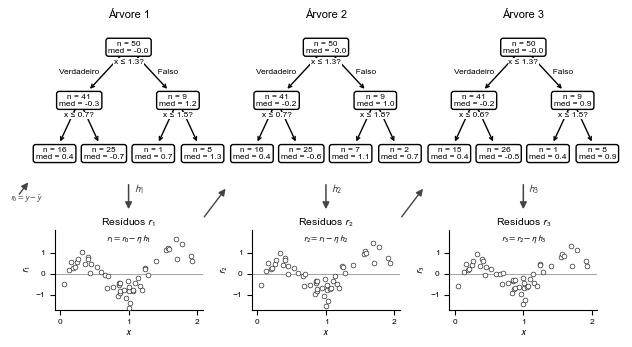

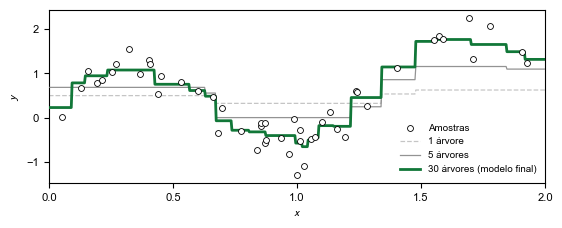

In [4]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch
from sklearn.tree import DecisionTreeRegressor, plot_tree
import numpy as np

cm = 1 / 2.54

plt.rcParams.update({
    "font.family": "Arial",
    "mathtext.fontset": "stixsans",
    "font.size": 8,
})

COR_XGB = "#117738"
COR_SETA = "#444444"


def encurtar_texto(text):
    return (text
            .replace("True", "Verdadeiro")
            .replace("False", "Falso")
            .replace("samples", "n")
            .replace("value", "med"))


def reformatar_arvore(ax, fig, fontsize_condicao=6):
    # Passo 1: alterar textos e guardar condicoes pendentes
    pendentes = []
    for ann in list(ax.texts):
        original = ann.get_text()
        encurtado = encurtar_texto(original)
        if "x <=" in encurtado:
            linhas = encurtado.split("\n")
            linha_condicao = linhas[0]
            resto = "\n".join(linhas[1:])
            condicao_bonita = linha_condicao.replace("<=", "≤") + "?"
            ann.set_text(resto)
            pendentes.append((ann, condicao_bonita))
        else:
            if encurtado != original:
                ann.set_text(encurtado)

    fig.canvas.draw()
    renderer = fig.canvas.get_renderer()

    # Passo 2: posicionar a condicao logo abaixo do bbox novo
    for ann, condicao in pendentes:
        patch = ann.get_bbox_patch()
        if patch is not None:
            bbox = patch.get_window_extent(renderer)
        else:
            bbox = ann.get_window_extent(renderer)
        bbox_axes = bbox.transformed(ax.transAxes.inverted())
        x_centro = (bbox_axes.x0 + bbox_axes.x1) / 2
        y_inferior = bbox_axes.y0
        ax.text(
            x_centro, y_inferior - 0.018, condicao,
            ha="center", va="top",
            fontsize=fontsize_condicao,
            transform=ax.transAxes, zorder=200,
            bbox=dict(facecolor="white", edgecolor="none",
                      boxstyle="square,pad=0.08"),
        )


def f_true(x):
    return np.sin(1.5 * np.pi * x) + 0.5 * x


def add_axes_centered(fig, center_x, center_y, w, h):
    return fig.add_axes([center_x - w / 2, center_y - h / 2, w, h])


# ============================================================
# Dados de treino e funcao verdadeira
# ============================================================
np.random.seed(2)
n_data = 50
x_train = np.sort(np.random.uniform(0, 2, n_data))
y_train = f_true(x_train) + 0.30 * np.random.randn(n_data)
x_grid = np.linspace(0, 2, 600)

# ============================================================
# Boosting sequencial
# ============================================================
M = 30
max_depth = 2
eta = 0.15

F_grid = np.zeros((M + 1, len(x_grid)))
F_train = np.zeros((M + 1, n_data))
F_grid[0] = y_train.mean()
F_train[0] = y_train.mean()
trees = []

for k in range(M):
    r = y_train - F_train[k]
    tree = DecisionTreeRegressor(max_depth=max_depth, random_state=k)
    tree.fit(x_train.reshape(-1, 1), r)
    trees.append(tree)
    F_grid[k + 1] = F_grid[k] + eta * tree.predict(x_grid.reshape(-1, 1))
    F_train[k + 1] = F_train[k] + eta * tree.predict(x_train.reshape(-1, 1))

saidas = [y_train - F_train[1], y_train - F_train[2], y_train - F_train[3]]

titulos_res = [r"Resíduos $r_1$", r"Resíduos $r_2$", r"Resíduos $r_3$"]
equacoes = [
    r"$r_1 = r_0 - \eta\,h_1$",
    r"$r_2 = r_1 - \eta\,h_2$",
    r"$r_3 = r_2 - \eta\,h_3$",
]
ylabel_res = [r"$r_1$", r"$r_2$", r"$r_3$"]

# ============================================================
# Figura 1: arvores em cima, residuos embaixo (com setas)
# ============================================================
fig1 = plt.figure(figsize=(16 * cm, 9 * cm))

left_margin = 0.05
right_margin = 0.99

# linha 1: arvores
top_y0 = 0.50
top_h = 0.45

# linha 2: residuos
mid_y0_base = 0.115
mid_h_base = 0.265

# tamanho dos residuos: menor que o slot, mas centralizado
res_w_scale = 0.75
res_h_scale = 0.85

mid_h = mid_h_base * res_h_scale
mid_center_y = mid_y0_base + mid_h_base / 2

# arvores
col_w_trees = (right_margin - left_margin) / 3
ax_trees = []
for i in range(3):
    x0 = left_margin + i * col_w_trees
    ax_trees.append(fig1.add_axes([x0, top_y0, col_w_trees, top_h]))

# residuos
slot_w_res = (right_margin - left_margin) / 3
col_w_res = slot_w_res * res_w_scale
res_centers_x = [left_margin + slot_w_res * (i + 0.5) for i in range(3)]

ax_res = [add_axes_centered(fig1, cx, mid_center_y, col_w_res, mid_h)
          for cx in res_centers_x]

# arvores
for k, ax in enumerate(ax_trees):
    plot_tree(
        trees[k], ax=ax, feature_names=["x"], filled=False,
        rounded=True, precision=1, fontsize=6,
        impurity=False, label="all",
    )
    reformatar_arvore(ax, fig1, fontsize_condicao=6)
    ax.set_title(f"Árvore {k + 1}", fontsize=8, pad=2)

# residuos
scatter_kw = dict(c="white", edgecolors="black", linewidth=0.4, s=12, zorder=3)
ylim_res = (-1.7, 2.1)

for k, ax in enumerate(ax_res):
    ax.scatter(x_train, saidas[k], **scatter_kw)
    ax.axhline(0, color="gray", linewidth=0.5, zorder=1)
    ax.set_xlim(-0.08, 2.08)
    ax.set_ylim(*ylim_res)
    ax.set_xticks([0, 1, 2])
    ax.set_yticks([-1, 0, 1])
    ax.tick_params(labelsize=6)
    ax.set_xlabel(r"$x$", fontsize=7, labelpad=2)
    ax.set_ylabel(ylabel_res[k], fontsize=7, labelpad=2)
    ax.set_title(titulos_res[k], fontsize=7.5, pad=3)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.text(
        0.5, 0.96, equacoes[k], ha="center", va="top", fontsize=6.5,
        transform=ax.transAxes,
        bbox=dict(facecolor="white", edgecolor="none",
                  boxstyle="square,pad=0.15")
    )

fig1.canvas.draw()

# ============================================================
# setas de fluxo
# ============================================================
for k in range(3):
    pos_tree = ax_trees[k].get_position()
    pos_res = ax_res[k].get_position()
    x_arrow = (pos_tree.x0 + pos_tree.x1) / 2
    y_start = pos_tree.y0 - 0.005
    y_end = pos_res.y1 + 0.050

    arrow = FancyArrowPatch(
        (x_arrow, y_start), (x_arrow, y_end),
        transform=fig1.transFigure, arrowstyle="-|>",
        color=COR_SETA, lw=1.1, mutation_scale=10, zorder=50
    )
    fig1.add_artist(arrow)

    fig1.text(
        x_arrow + 0.008, y_start - 0.002, rf"$h_{{{k+1}}}$",
        ha="left", va="top", fontsize=8, color=COR_SETA, zorder=100,
        bbox=dict(facecolor="white", edgecolor="none",
                  boxstyle="square,pad=0.2")
    )

for k in range(2):
    pos_res = ax_res[k].get_position()
    pos_tree_next = ax_trees[k + 1].get_position()

    arrow = FancyArrowPatch(
        (pos_res.x1, pos_res.y1 + 0.030),
        (pos_tree_next.x0, pos_tree_next.y0 - 0.018),
        transform=fig1.transFigure, arrowstyle="-|>",
        color=COR_SETA, lw=1.0, mutation_scale=10, zorder=50
    )
    fig1.add_artist(arrow)

pos_tree0 = ax_trees[0].get_position()
pos_res0 = ax_res[0].get_position()
pos_tree1 = ax_trees[1].get_position()

dx = (pos_tree1.x0 - pos_res0.x1) / 2
dy = ((pos_tree1.y0 - 0.018) - (pos_res0.y1 + 0.030)) / 2

x_end = pos_tree0.x0
y_end = pos_tree0.y0
x_start = x_end - dx
y_start = y_end - dy

arrow = FancyArrowPatch(
    (x_start, y_start), (x_end, y_end),
    transform=fig1.transFigure, arrowstyle="-|>",
    color=COR_SETA, lw=1.0, mutation_scale=10, zorder=50
)
fig1.add_artist(arrow)

fig1.text(
    x_start - 0.012, y_start - 0.012, r"$r_0 = y - \bar{y}$",
    fontsize=6, color=COR_SETA,
    bbox=dict(facecolor="white", edgecolor="none",
              boxstyle="square,pad=0.15")
)

plt.savefig("figuras/exemplo_xgboost1.png", dpi=300)

# ============================================================
# Figura 2: progressao do ensemble
# ============================================================
fig2, ax_agg = plt.subplots(figsize=(14 * cm, 5.5 * cm), layout="constrained")

ax_agg.scatter(x_train, y_train, c="white", edgecolors="black",
               linewidth=0.6, s=18, marker="o", zorder=5,
               label="Amostras")

ax_agg.plot(x_grid, F_grid[1], color="gray", linewidth=0.9, alpha=0.45,
            linestyle="--", zorder=2, label="1 árvore")
ax_agg.plot(x_grid, F_grid[5], color="gray", linewidth=0.9, alpha=0.85,
            zorder=3, label="5 árvores")
ax_agg.plot(x_grid, F_grid[M], color=COR_XGB, linewidth=2.0,
            zorder=4, label=f"{M} árvores (modelo final)")

ax_agg.set_xlim(0, 2)
ax_agg.set_xticks(np.arange(0, 2.1, 0.5))
ax_agg.set_xlabel(r"$x$")
ax_agg.set_ylabel(r"$y$")
ax_agg.legend(loc="lower right", fontsize=7, frameon=False)

plt.savefig("figuras/exemplo_xgboost2.png", dpi=300)